# H4 — Métodos de Pago y Ticket Promedio

**Hipótesis:** Las compras pagadas con tarjeta de crédito en cuotas (≥ 3 cuotas)
tienen un ticket promedio al menos 3 veces mayor que los pagos de contado.

**Herramientas:** PySpark (groupBy, when/otherwise, aggregations) · Matplotlib · Seaborn

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

HDFS         = os.environ.get('HADOOP_NAMENODE', 'hdfs://namenode:8020')
SPARK_MASTER = os.environ.get('SPARK_MASTER',   'spark://spark-master:7077')
DATA_PATH    = f'{HDFS}/data/olist'
OUT          = '/home/jovyan/work/outputs/graficas'
os.makedirs(OUT, exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 130

In [2]:
spark = SparkSession.builder \
    .appName('H4_Metodos_Pago') \
    .master(SPARK_MASTER) \
    .config('spark.hadoop.fs.defaultFS', HDFS) \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()
spark.sparkContext.setLogLevel('WARN')

26/04/17 17:36:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


In [3]:
payments = spark.read.csv(f'{DATA_PATH}/order_payments.csv', header=True, inferSchema=True)
orders   = spark.read.csv(f'{DATA_PATH}/orders.csv',         header=True, inferSchema=True)

delivered = orders.filter(F.col('order_status') == 'delivered').select('order_id')

pay = payments.join(delivered, 'order_id') \
    .withColumn('tipo_pago',
        F.when((F.col('payment_type') == 'credit_card') & (F.col('payment_installments') >= 3),
               'Crédito (>=3 cuotas)')
         .when((F.col('payment_type') == 'credit_card') & (F.col('payment_installments') < 3),
               'Crédito (1-2 cuotas)')
         .when(F.col('payment_type') == 'boleto',    'Boleto bancário')
         .when(F.col('payment_type') == 'debit_card','Tarjeta débito')
         .otherwise('Voucher / Otro')
    )

stats = pay.groupBy('tipo_pago').agg(
    F.avg('payment_value').alias('ticket_promedio'),
    F.count('order_id').alias('n_ordenes'),
    F.sum('payment_value').alias('revenue_total'),
    F.avg('payment_installments').alias('cuotas_promedio')
).toPandas().sort_values('ticket_promedio', ascending=False)

stats['ticket_promedio'] = stats['ticket_promedio'].round(2)
print(stats[['tipo_pago','ticket_promedio','n_ordenes','cuotas_promedio']].to_string(index=False))

           tipo_pago  ticket_promedio  n_ordenes  cuotas_promedio
Crédito (>=3 cuotas)           401.52      20376         6.779446
      Voucher / Otro           242.00       4312         1.000000
     Boleto bancário           239.39      11333         1.000000
      Tarjeta débito           239.39       3085         1.000000
Crédito (1-2 cuotas)           103.39      23696         1.498692


### Gráfica 1 — Ticket promedio por tipo de pago

/tmp/ipykernel_1728/3605470366.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(stats['tipo_pago'], rotation=20, ha='right')


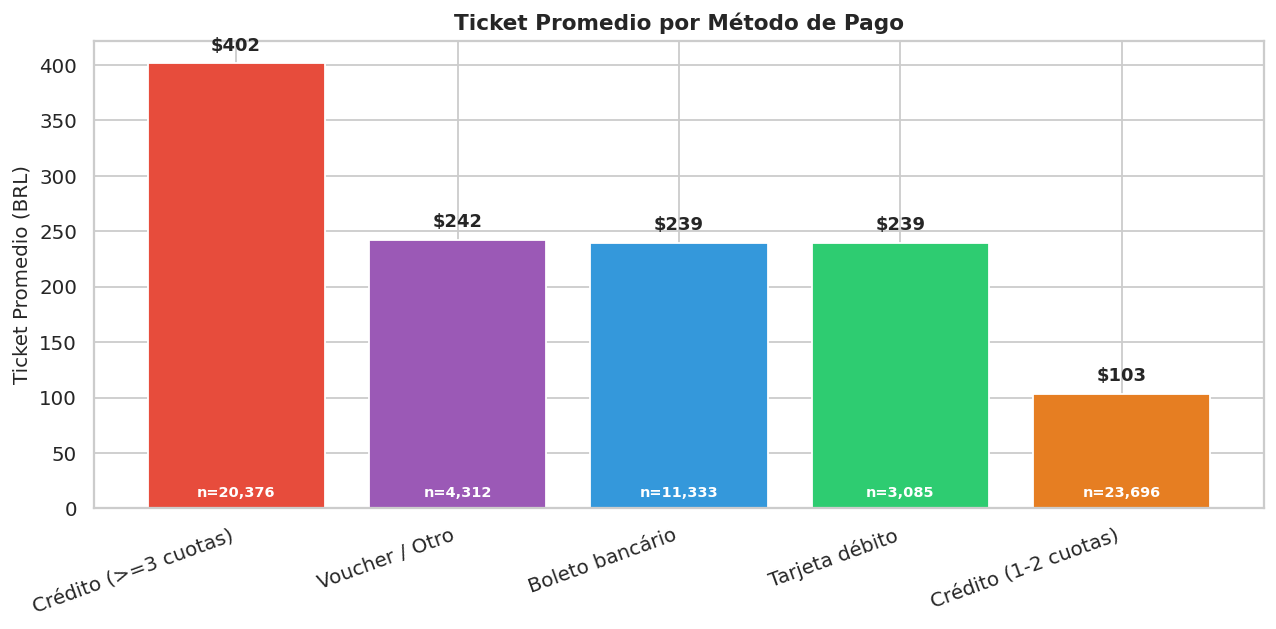

In [4]:
colors_map = {
    'Crédito (>=3 cuotas)': '#e74c3c',
    'Crédito (1-2 cuotas)': '#e67e22',
    'Boleto bancário':      '#3498db',
    'Tarjeta débito':       '#2ecc71',
    'Voucher / Otro':       '#9b59b6',
}
bar_colors = [colors_map.get(t, '#95a5a6') for t in stats['tipo_pago']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(stats['tipo_pago'], stats['ticket_promedio'], color=bar_colors, edgecolor='white')
ax.bar_label(bars, labels=[f'${v:,.0f}' for v in stats['ticket_promedio']],
             padding=5, fontsize=10, fontweight='bold')
ax.set_ylabel('Ticket Promedio (BRL)', fontsize=11)
ax.set_title('Ticket Promedio por Método de Pago', fontsize=12, fontweight='bold')
ax.set_xticklabels(stats['tipo_pago'], rotation=20, ha='right')
for i, (_, row) in enumerate(stats.iterrows()):
    ax.text(i, 10, f"n={row['n_ordenes']:,}", ha='center', fontsize=8, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/H4_ticket_por_pago.png', bbox_inches='tight')
plt.show()

### Gráfica 2 — Distribución del valor de pago (boxplot)

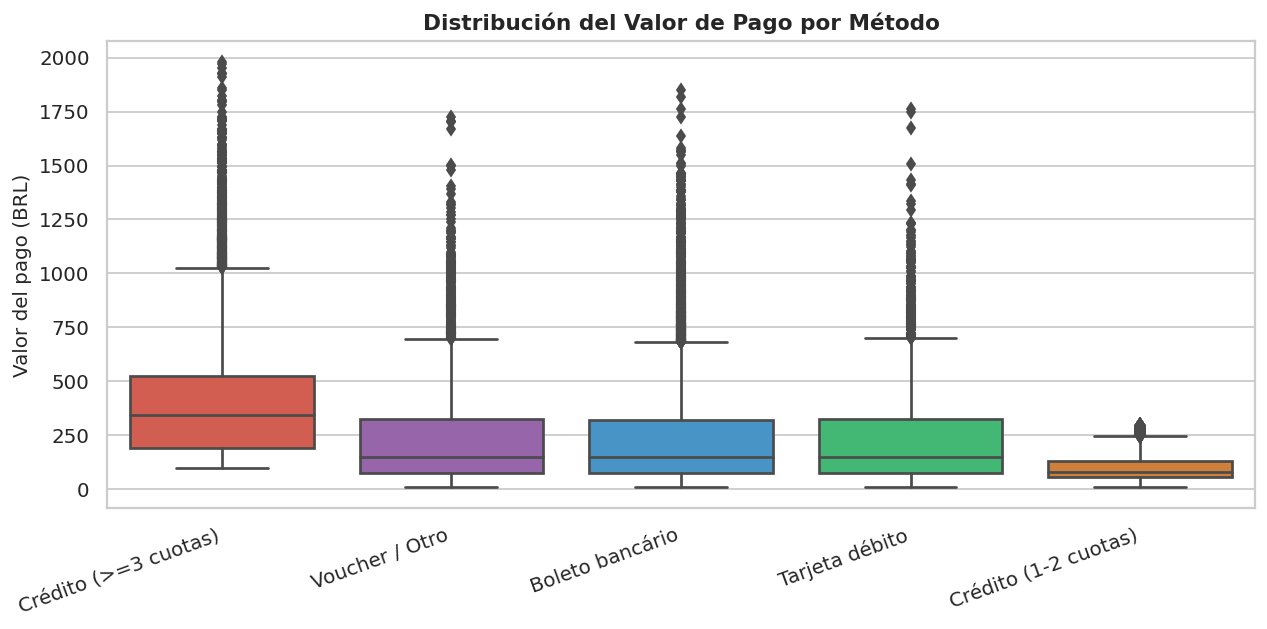

In [5]:
pay_sample = pay.filter(F.col('payment_value') < 2000) \
    .select('tipo_pago', 'payment_value').toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=pay_sample, x='tipo_pago', y='payment_value',
            order=stats['tipo_pago'].tolist(), palette=colors_map, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Valor del pago (BRL)', fontsize=11)
ax.set_title('Distribución del Valor de Pago por Método', fontsize=12, fontweight='bold')
ax.set_xticklabels(stats['tipo_pago'].tolist(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig(f'{OUT}/H4_boxplot_pagos.png', bbox_inches='tight')
plt.show()

### Gráfica 3 — Cuotas vs Ticket Promedio (tarjeta crédito)

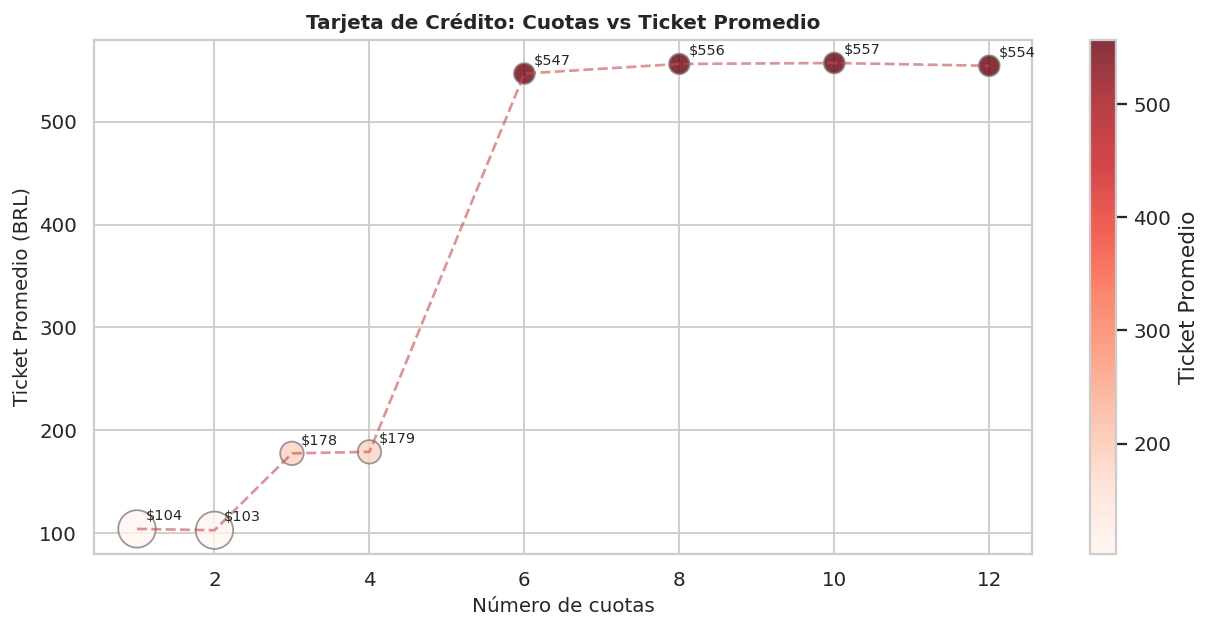

In [6]:
cc_data = payments.join(delivered, 'order_id') \
    .filter(F.col('payment_type') == 'credit_card') \
    .groupBy('payment_installments').agg(
        F.avg('payment_value').alias('ticket_promedio'),
        F.count('order_id').alias('n')
    ).orderBy('payment_installments').toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(cc_data['payment_installments'], cc_data['ticket_promedio'],
                s=cc_data['n'] / cc_data['n'].max() * 400 + 30,
                c=cc_data['ticket_promedio'], cmap='Reds', alpha=0.8, edgecolors='grey')
ax.plot(cc_data['payment_installments'], cc_data['ticket_promedio'], 'r--', linewidth=1.5, alpha=0.6)
for _, row in cc_data.iterrows():
    ax.annotate(f"${row['ticket_promedio']:.0f}",
                (row['payment_installments'], row['ticket_promedio']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)
ax.set_xlabel('Número de cuotas', fontsize=11)
ax.set_ylabel('Ticket Promedio (BRL)', fontsize=11)
ax.set_title('Tarjeta de Crédito: Cuotas vs Ticket Promedio', fontsize=11, fontweight='bold')
plt.colorbar(sc, label='Ticket Promedio')
plt.tight_layout()
plt.savefig(f'{OUT}/H4_cuotas_ticket.png', bbox_inches='tight')
plt.show()

### Conclusión H4

In [7]:
t_cuotas  = stats[stats['tipo_pago'] == 'Crédito (>=3 cuotas)']['ticket_promedio'].values[0]
t_contado = stats[stats['tipo_pago'].isin(['Boleto bancário','Tarjeta débito'])]['ticket_promedio'].mean()
ratio     = t_cuotas / t_contado

print(f'Ticket promedio — crédito >=3 cuotas: ${t_cuotas:,.2f}')
print(f'Ticket promedio — pago contado:       ${t_contado:,.2f}')
print(f'Ratio:                                {ratio:.2f}x')
print()
if ratio >= 3:
    print('CONCLUSIÓN: La hipótesis SE CONFIRMA.')
else:
    print(f'CONCLUSIÓN: Hipótesis PARCIALMENTE confirmada (ratio = {ratio:.1f}x).')
print(f'  Comprar en cuotas se asocia con tickets {ratio:.1f}x más altos.')

Ticket promedio — crédito >=3 cuotas: $401.52
Ticket promedio — pago contado:       $239.39
Ratio:                                1.68x

CONCLUSIÓN: Hipótesis PARCIALMENTE confirmada (ratio = 1.7x).
  Comprar en cuotas se asocia con tickets 1.7x más altos.


In [8]:
spark.stop()